In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pickle
import os, sys, shutil
import pandas as pd
import json
import importlib
#sys.path.insert(0, 'Solar_Gap_Filling/utils')
sys.path.append('/pl/active/NSO-IT/data/leah/Solar_GapFilling/GONG_GapFilling/')
from utils import data_utils, run_utils, eval_utils, plot_utils, models

In [2]:
'''
Quickly summarize trained models
'''

importlib.reload(eval_utils)

ignore_cols = []
mods = eval_utils.get_modelDF(modeldir='../../model_runs', tag='', metric='Selected_RMSE')
eval_utils.display_DF(mods, ignore_cols)

Skipping SimpleRNN2; not finished training
Skipping SimpleRNN3; not finished training


,name,model_name,img_size,loss_name,num_epochs,batch_size,learning_rate,Selected_RMSE,padding_mode,kernel_size
0,SimpleRNN1,SimpleRNN,128,MSE,3,16,0.01,0.094659,NaN,NaN
1,UNet1,UNet,128,MSE,20,16,0.10,0.101911,NaN,NaN
2,SimpleCNN2,NaN,128,MSE,10,16,0.01,0.236357,replicate,3.0
3,UNet2,UNet,128,MSE,100,16,0.10,0.098868,NaN,NaN
4,SimpleCNN1,NaN,128,MSE,5,16,0.10,0.231961,replicate,3.0
5,SimpleCNN3,NaN,128,Selected_MSE,20,16,0.01,0.098971,replicate,3.0


[Text(0.5, 1.0, 'UNet1 losses'), Text(0, 0.5, 'Loss'), Text(0.5, 0, 'Epoch')]

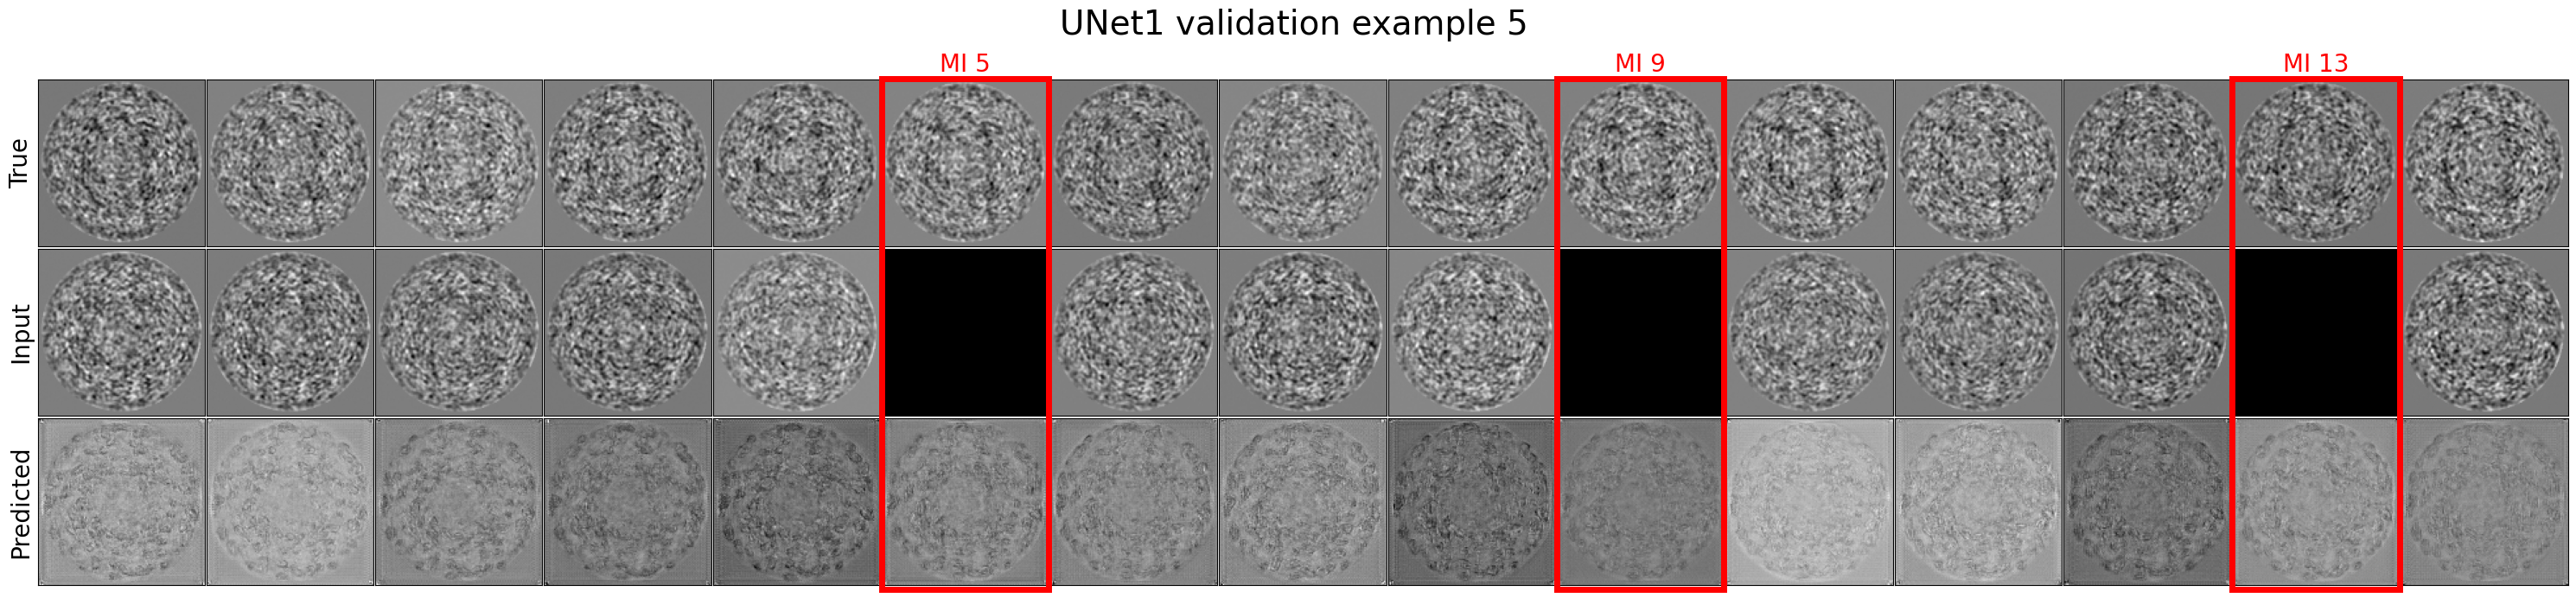

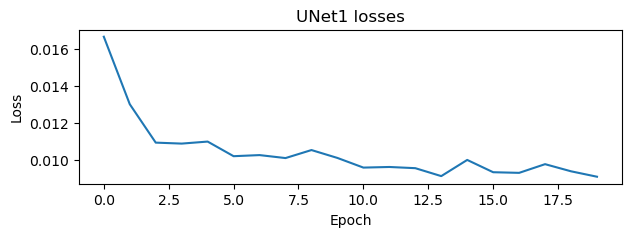

In [98]:
'''
Show example predictions for one model 
'''
importlib.reload(plot_utils)

model_name = 'UNet1'

# Plot one validation example 
fig = plot_utils.plot_preds_one_model_single(model_name, output_dir='../../model_runs/',  example_idx=5)

# Plot losses
losses = np.load(f'../../model_runs/{model_name}/losses.npy')
fig, ax = plt.subplots(1, 1, figsize=(7, 2))
ax.plot(losses)
ax.set(title=f'{model_name} losses', ylabel='Loss', xlabel='Epoch')
